In [120]:
from datamodel import Order, OrderDepth, Product
from statistics import NormalDist
from math import sqrt, log, pi, exp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

In [121]:
md = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R4\round-4-island-data-bottle\prices_round_4_day_1.csv", sep=";", header=0)
od = pd.read_csv(r"C:\Users\Can\OneDrive\Desktop\IMC\R4\round-4-island-data-bottle\observations_round_4_day_1.csv", sep=",", header=0)
md = md[md['product'] == 'MAGNIFICENT_MACARONS'].reset_index()
md = md.iloc[:1000,:]
od = od.iloc[:1000,:]

In [122]:
import pandas as pd
import re
import json

with open('t1.log', "r", encoding="utf-8") as f:
    content = f.read()

cut_content = content.split("Activities log:")[0]
log_lines = [line.strip() for line in cut_content.splitlines() if line.strip()]

json_blocks = []
temp_block = ""
brace_count = 0
for line in log_lines:
    brace_count += line.count("{") - line.count("}")
    temp_block += line
    if brace_count == 0 and temp_block:
        try:
            json_blocks.append(json.loads(temp_block))
        except:
            pass
        temp_block = ""

data = []
for entry in json_blocks:
    timestamp = entry.get("timestamp")
    match = re.search(r"MAGNIFICENT_MACARONS:\s*(-?\d+)", entry.get("lambdaLog", ""))
    if match:
        position = int(match.group(1))
        data.append({"timestamp": timestamp, "macaron_position": position})

df = pd.DataFrame(data)

In [123]:
def _process_data_(file):
    with open(file, 'r') as file:
        log_content = file.read()
    sections = log_content.split('Sandbox logs:')[1].split('Activities log:')
    my_data = sections[0].strip()
    sandbox_log =  sections[0].strip()
    activities_log = sections[1].split('Trade History:')[0]
    # sandbox_log_list = [json.loads(line) for line in sandbox_log.split('\n')]
    trade_history =  json.loads(sections[1].split('Trade History:')[1])
    # sandbox_log_df = pd.DataFrame(sandbox_log_list)
    market_data_df = pd.read_csv(io.StringIO(activities_log), sep=";", header=0)
    trade_history_df = pd.json_normalize(trade_history)
    return market_data_df, trade_history_df, my_data

online, _, _ = _process_data_('t1.log')

In [124]:
online = online[online['product'] == 'MAGNIFICENT_MACARONS']

md['bid'] = od['bidPrice'] - od['exportTariff'] - od['transportFees']
md['ask'] = od['askPrice'] + od['importTariff'] +  od['transportFees']

In [128]:
md

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,bid,ask
0,6,1,0,MAGNIFICENT_MACARONS,624.0,20.0,622.0,12.0,617.0,23.0,631,10,639.0,23.0,644.0,12.0,627.5,0.0,617.0,626.5
1,29,1,100,MAGNIFICENT_MACARONS,627.0,14.0,625.0,12.0,620.0,21.0,634,7,642.0,21.0,647.0,12.0,630.5,0.0,620.0,629.5
2,41,1,200,MAGNIFICENT_MACARONS,627.0,10.0,625.0,15.0,620.0,21.0,634,5,642.0,21.0,647.0,15.0,630.5,0.0,620.0,629.5
3,47,1,300,MAGNIFICENT_MACARONS,629.0,14.0,627.0,14.0,622.0,26.0,636,7,644.0,26.0,649.0,14.0,632.5,0.0,622.0,631.5
4,73,1,400,MAGNIFICENT_MACARONS,628.0,18.0,625.0,16.0,620.0,26.0,635,9,643.0,26.0,648.0,16.0,631.5,0.0,620.5,630.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,14932,1,99500,MAGNIFICENT_MACARONS,627.0,16.0,625.0,13.0,619.0,20.0,635,8,643.0,20.0,649.0,13.0,631.0,0.0,619.5,630.0
996,14947,1,99600,MAGNIFICENT_MACARONS,625.0,16.0,623.0,13.0,618.0,28.0,633,8,641.0,28.0,647.0,13.0,629.0,0.0,618.0,628.0
997,14955,1,99700,MAGNIFICENT_MACARONS,625.0,14.0,623.0,12.0,617.0,26.0,633,7,641.0,26.0,646.0,12.0,629.0,0.0,617.5,627.5
998,14973,1,99800,MAGNIFICENT_MACARONS,625.0,10.0,623.0,14.0,617.0,25.0,633,5,641.0,25.0,646.0,14.0,629.0,0.0,617.5,627.5


C:\Users\Can\AppData\Local\Temp\ipykernel_32744\1152108935.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()
C:\Users\Can\AppData\Local\Temp\ipykernel_32744\1152108935.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()
C:\Users\Can\AppData\Local\Temp\ipykernel_32744\1152108935.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3].legend()


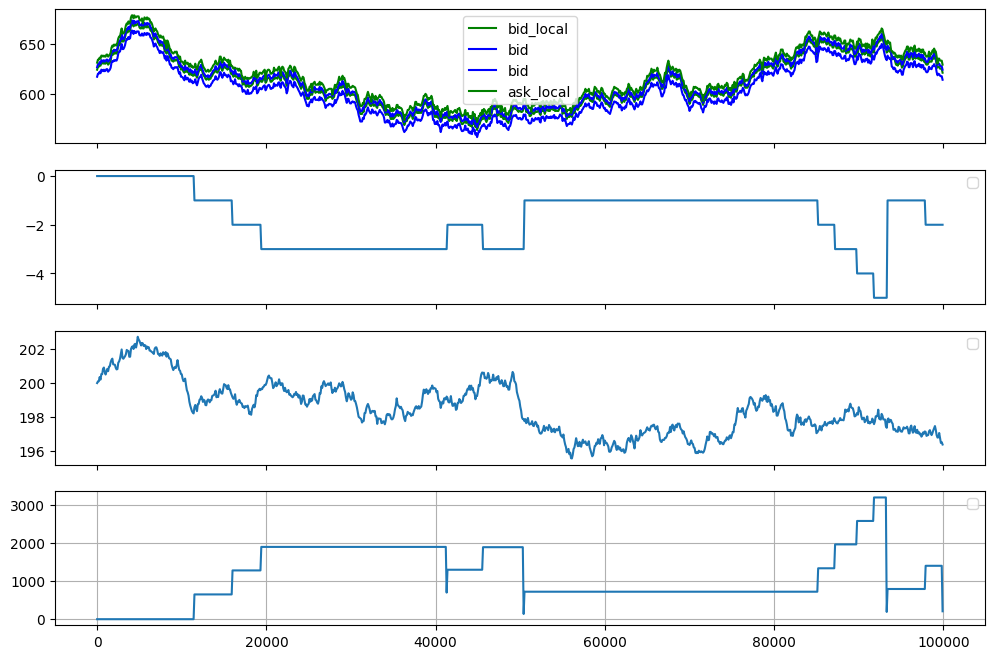

In [126]:
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

ax[0].plot(md['timestamp'], md['bid_price_1'], label="bid_local", color='green')
ax[0].plot(md['timestamp'], md['ask'], label="bid", color='blue')

ax[0].plot(md['timestamp'], md['bid'], label="bid", color='blue')
ax[0].plot(md['timestamp'], md['ask_price_1'], label="ask_local", color='green')

ax[1].plot(md['timestamp'],df.macaron_position)

ax[2].plot(md['timestamp'],od.sugarPrice)
ax[3].plot(md['timestamp'],online.profit_and_loss)
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
plt.grid(True)
plt.show()